In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix


# CLEAN DATASET

In [5]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [6]:
df = df[['v1', 'v2']]
df = df.rename(columns={'v1': 'label', 'v2': 'message'})

# Check the data
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# EDA

In [7]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

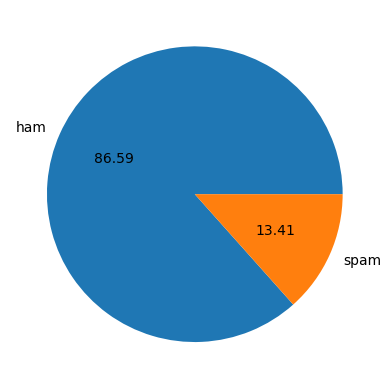

In [8]:
plt.pie(df['label'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

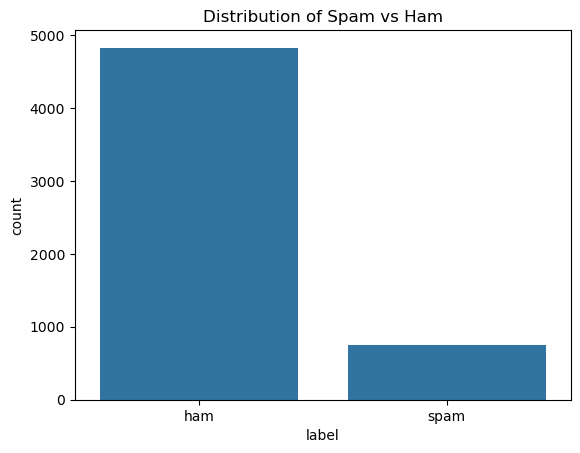

label
ham     4825
spam     747
Name: count, dtype: int64

In [9]:
# Count spam vs ham
sns.countplot(x='label', data=df)
plt.title("Distribution of Spam vs Ham")
plt.show()

df['label'].value_counts()


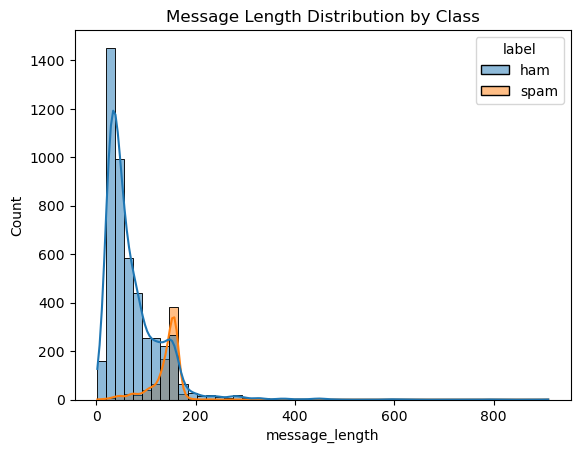

In [10]:
df['message_length'] = df['message'].apply(len)

sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True)
plt.title("Message Length Distribution by Class")
plt.show()

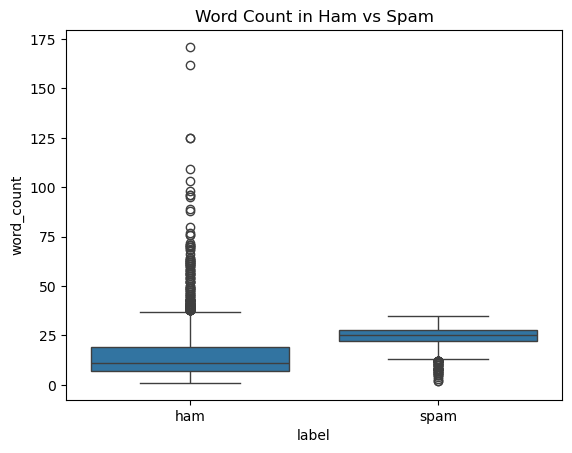

In [11]:
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

sns.boxplot(x='label', y='word_count', data=df)
plt.title("Word Count in Ham vs Spam")
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['label_num'] = encoder.fit_transform(df['label'])
df.head()


,label,message,message_length,word_count,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,0
1,ham,Ok lar... Joking wif u oni...,29,6,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1
3,ham,U dun say so early hor... U c already then say...,49,11,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,0


# TEXT PROCESSING

In [13]:
import re
import string
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = ' '.join([word for word in text.split() if word not in stop_words])  # remove stopwords
    return text

df['clean_message'] = df['message'].apply(clean_text)
df.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alok_\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,message,message_length,word_count,label_num,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,0,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,29,6,0,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,49,11,0,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,0,nah dont think goes usf lives around though


# VECTORIZATION

In [14]:
# Split features and labels
X = df['clean_message']
y = df['label_num']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Shape of TF-IDF matrix:", X_train_tfidf.shape)



Shape of TF-IDF matrix: (4457, 3000)


In [15]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(X_train_tfidf,y_train)

MultinomialNB()

# LOGISTIC REGRESSION MODEL

Classification Report (Logistic Regression):

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       965
        Spam       0.96      0.66      0.78       150

    accuracy                           0.95      1115
   macro avg       0.96      0.83      0.88      1115
weighted avg       0.95      0.95      0.95      1115



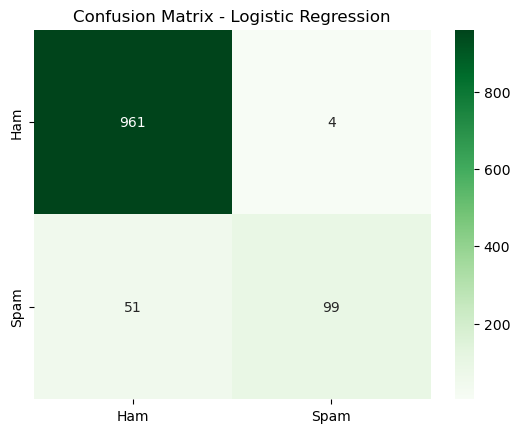

In [16]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_tfidf)

# Evaluation
print("Classification Report (Logistic Regression):\n")
print(classification_report(y_test, y_pred_lr, target_names=['Ham', 'Spam']))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens", xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title("Confusion Matrix - Logistic Regression")
plt.show()



# Naive bayes model

Classification Report:

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       965
        Spam       1.00      0.79      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



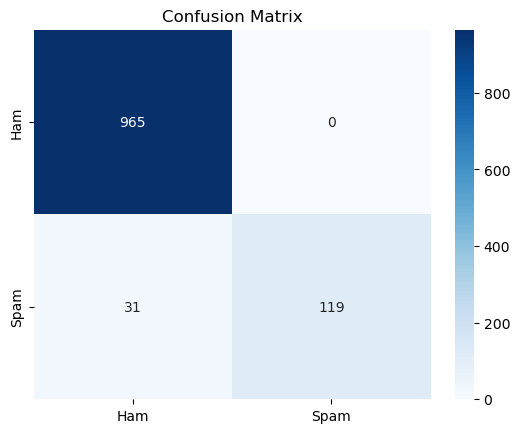

In [17]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

# Predictions
y_pred = nb.predict(X_test_tfidf)

# Evaluation
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title("Confusion Matrix")
plt.show()



# ACCURACY

In [18]:
from sklearn.metrics import accuracy_score

acc_nb = accuracy_score(y_test, y_pred)
print("Naive Bayes Accuracy:", acc_nb)
conf_matrix=confusion_matrix(y_test,y_pred)
print("confusion matrix:\n",conf_matrix)
class_report=classification_report(y_test,y_pred)
print("classification report:\n",class_report)


acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", acc_lr)
conf_matrix=confusion_matrix(y_test,y_pred_lr)
print("confusion matrix:\n",conf_matrix)
class_report=classification_report(y_test,y_pred_lr)
print("classification report:\n",class_report)



Naive Bayes Accuracy: 0.9721973094170404
confusion matrix:
 [[965   0]
 [ 31 119]]
classification report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.79      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115

Logistic Regression Accuracy: 0.9506726457399103
confusion matrix:
 [[961   4]
 [ 51  99]]
classification report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.96      0.66      0.78       150

    accuracy                           0.95      1115
   macro avg       0.96      0.83      0.88      1115
weighted avg       0.95      0.95      0.95      1115



# TEST

In [19]:
def predict_message(message, model, vectorizer):
    clean = clean_text(message)
    vector = vectorizer.transform([clean])
    prediction = model.predict(vector)[0]
    return "Spam" if prediction == 1 else "Ham"

test_messages = [
    "WINNER!! You have won a free iPhone. Call now!!!",
    "Hey, are we still meeting for lunch today?",
    "URGENT! Claim your free vacation now.",
    "Don't forget to bring your homework."
]

for msg in test_messages:
    print(f"{msg} --> {predict_message(msg, nb, vectorizer)}")


WINNER!! You have won a free iPhone. Call now!!! --> Spam
Hey, are we still meeting for lunch today? --> Ham
URGENT! Claim your free vacation now. --> Spam
Don't forget to bring your homework. --> Ham


In [20]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


# CONCLUSION :
This project successfully demonstrated the use of machine learning techniques for SMS spam detection. 
Through text preprocessing, feature extraction using TF-IDF, and classification with models like Naive Bayes 
and Logistic Regression, the system achieved high accuracy in distinguishing spam from ham messages. 
The results highlight the effectiveness of supervised learning for text classification tasks.
With further improvements such as handling imbalanced data and testing on larger datasets,
the model can be enhanced for real-world deployment.